# Quickstart: one baseline run

This notebook runs one simple baseline simulation.
You can use it to check that the model and plots are working.


## Setup

This cell moves to repo root so relative paths work.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from skin_diffusion.notebook_helpers import setup_repo_root

# go to project root
repo_root = setup_repo_root()
print('repo_root:', repo_root)


repo_root: C:\Users\nwals\Documents\COMP3931_IndividualProject


## Run baseline config

This runs V1 and prints key outputs.


In [8]:
from skin_diffusion.config import load_config
from skin_diffusion.run_utils import run_simulation

# load baseline config
cfg = load_config('configs/sim/v1_baseline.yaml')

# run simulation
C_snap, t_save, D_field, k_field, patch_mask, diagnostics, metrics, stability_info = run_simulation(cfg)

print('C_snap:', C_snap.shape)
print('t_save:', t_save.shape)
print('D:', D_field.shape)
print('patch cells:', int(patch_mask.sum()))
print('J_ss:', metrics.get('J_ss'))
print('Tlag:', metrics.get('Tlag'))
print('P:', metrics.get('P'))


simulate: 100%|██████████| 40001/40001 [00:04<00:00, 8372.46it/s]


C_snap: (4001, 64, 64)
t_save: (4001,)
D: (64, 64)
patch cells: 32
J_ss: 1.4215015597532132
Tlag: 0.07925173129882652
P: 1.4215015597532132


## Heatmaps and depth profiles

Top row:
- concentration heatmap at start, middle, end.

Bottom row:
- depth profile (x-averaged concentration).


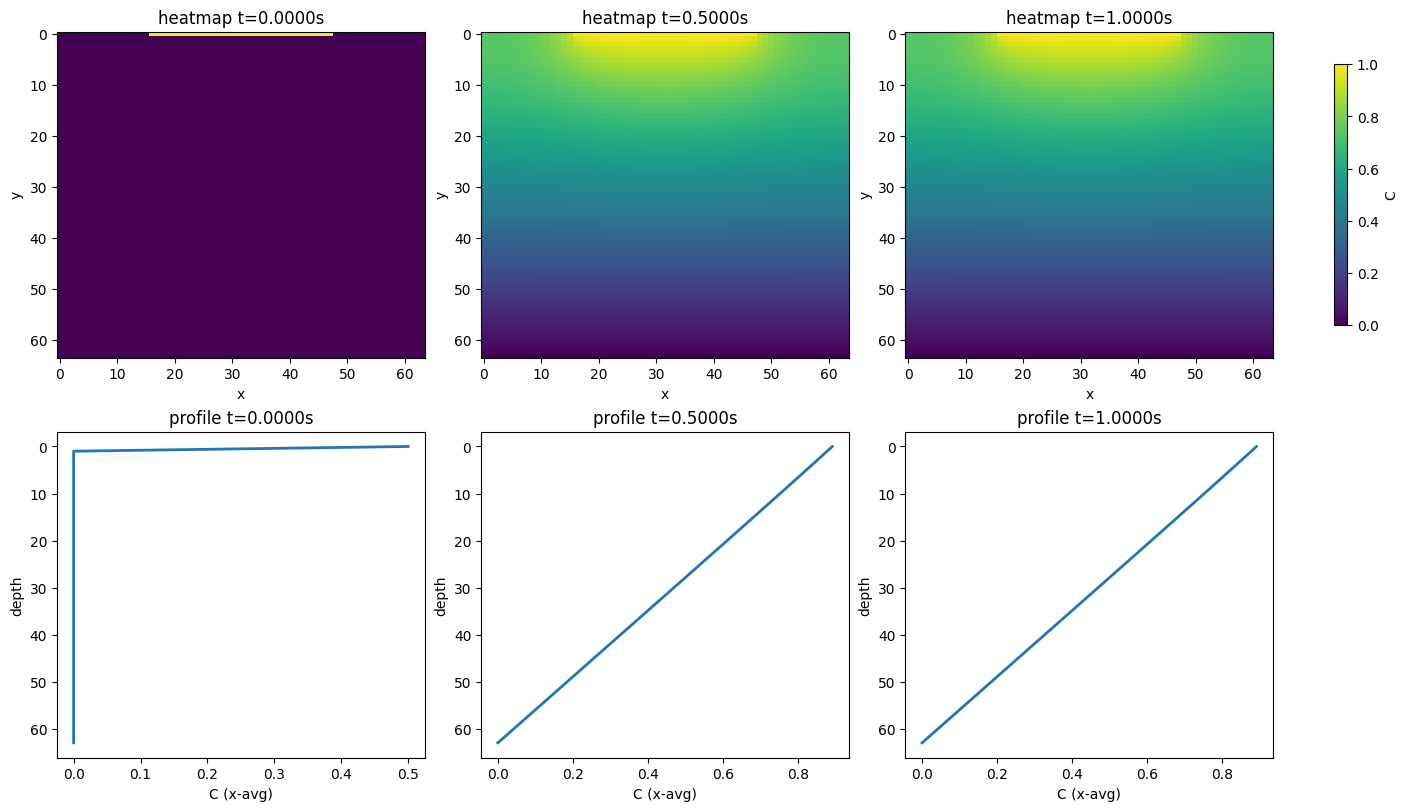

In [9]:
# pick 3 times: start, middle, end
idxs = [0, len(t_save) // 2, len(t_save) - 1]
depth = np.arange(C_snap.shape[1])
vmax = float(C_snap.max())

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for col in range(3):
    idx = idxs[col]

    # heatmap
    im = axes[0, col].imshow(C_snap[idx], origin='upper', aspect='auto', vmin=0.0, vmax=vmax)
    axes[0, col].set_title(f'heatmap t={t_save[idx]:.4f}s')
    axes[0, col].set_xlabel('x')
    axes[0, col].set_ylabel('y')

    # depth profile
    profile = C_snap[idx].mean(axis=1)
    axes[1, col].plot(profile, depth, lw=2)
    axes[1, col].invert_yaxis()
    axes[1, col].set_title(f'profile t={t_save[idx]:.4f}s')
    axes[1, col].set_xlabel('C (x-avg)')
    axes[1, col].set_ylabel('depth')

fig.colorbar(im, ax=axes[0, :], shrink=0.8, label='C')
plt.show()


## Flux, diagnostics, and patch mask

- Flux J(t): bottom flux over time.
- Diagnostics: total mass and minimum C.
- Patch mask: where donor is applied on top row.


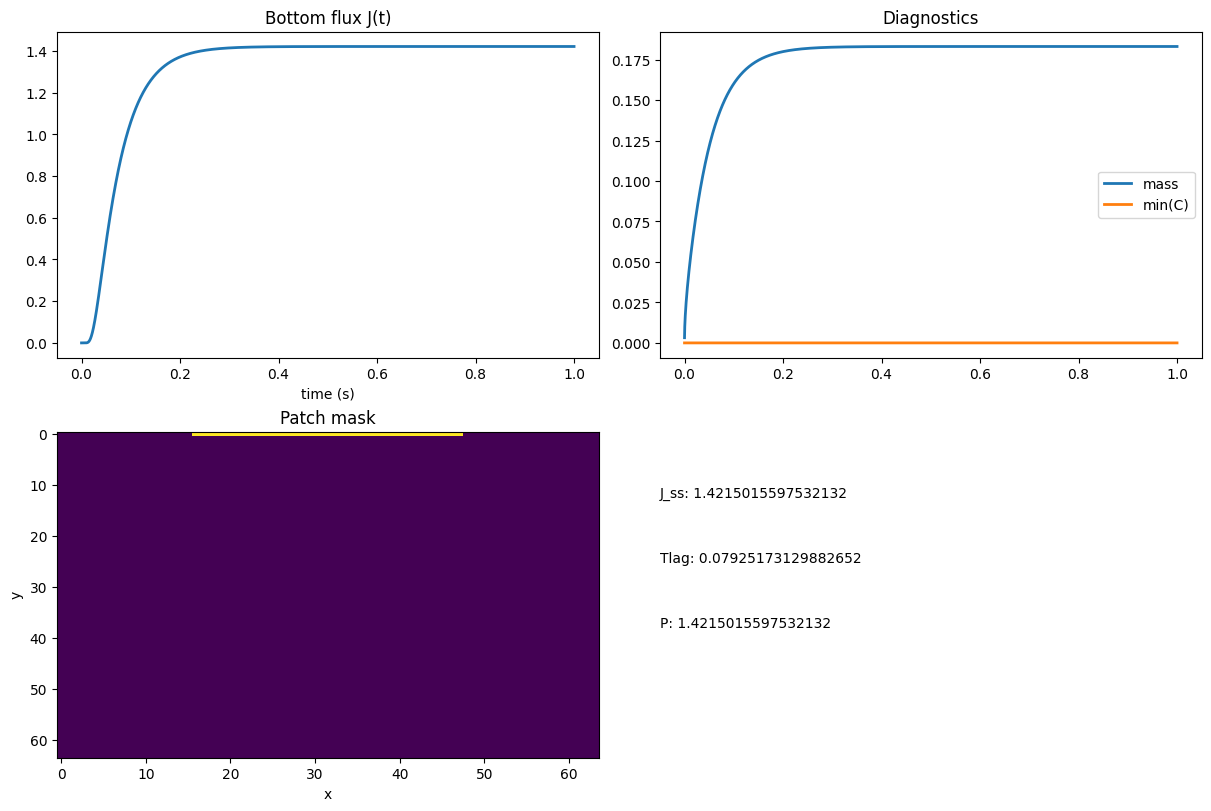

In [10]:
# read timeseries
J = np.array(metrics['J'], dtype=float)
t = np.array(metrics['t'], dtype=float)
mass = np.array(diagnostics['mass'], dtype=float)
min_c = np.array(diagnostics['min_value'], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# flux
axes[0, 0].plot(t, J, lw=2)
axes[0, 0].set_title('Bottom flux J(t)')
axes[0, 0].set_xlabel('time (s)')

# diagnostics
axes[0, 1].plot(t, mass, lw=2, label='mass')
axes[0, 1].plot(t, min_c, lw=2, label='min(C)')
axes[0, 1].set_title('Diagnostics')
axes[0, 1].legend()

# patch mask
axes[1, 0].imshow(patch_mask.astype(int), origin='upper', aspect='auto')
axes[1, 0].set_title('Patch mask')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')

# text summary
axes[1, 1].axis('off')
axes[1, 1].text(0.0, 0.8, f"J_ss: {metrics.get('J_ss')}")
axes[1, 1].text(0.0, 0.6, f"Tlag: {metrics.get('Tlag')}")
axes[1, 1].text(0.0, 0.4, f"P: {metrics.get('P')}")

plt.show()
